# IAA, Lab 2 : AI and Vision-based navigation
**Students: Emily Baquerizo & Kimberly Beyeler**

In [33]:
import os
import time
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.model_selection import train_test_split

# Exploration des données

## Import des données

In [2]:
DATA_ROOT = r"C:\Users\Victus\Documents\duckietown\datasets"
CSV_PATH  = DATA_ROOT + r"\labels.csv"
IMG_DIR   = DATA_ROOT + r"\images"
print(f"Dataset prêt : {len(os.listdir(IMG_DIR))} images trouvées")

Dataset prêt : 25205 images trouvées


## Affichages des données

In [3]:
df = pd.read_csv(CSV_PATH)
print(len(df))
df.head()

25205


,timestamp,image_name,vel_left,vel_right
0,1.770648e+09,1770647880.149484.jpg,0.225903,0.216678
1,1.770648e+09,1770647880.196790.jpg,0.225806,0.216775
2,1.770648e+09,1770647880.232433.jpg,0.225529,0.217052
3,1.770648e+09,1770647880.248546.jpg,0.207938,0.234643
4,1.770648e+09,1770647880.297955.jpg,0.208268,0.234313


In [4]:
df[["vel_left", "vel_right"]].describe()

,vel_left,vel_right
count,25205.000000,25205.000000
mean,0.219207,0.223374
std,0.045192,0.045192
min,0.072393,0.089099
25%,0.190551,0.204908
50%,0.217278,0.225303
75%,0.237673,0.252030
max,0.353482,0.370188


## Visualisation des données

Text(0.5, 1.0, 'Distribution velocity right')

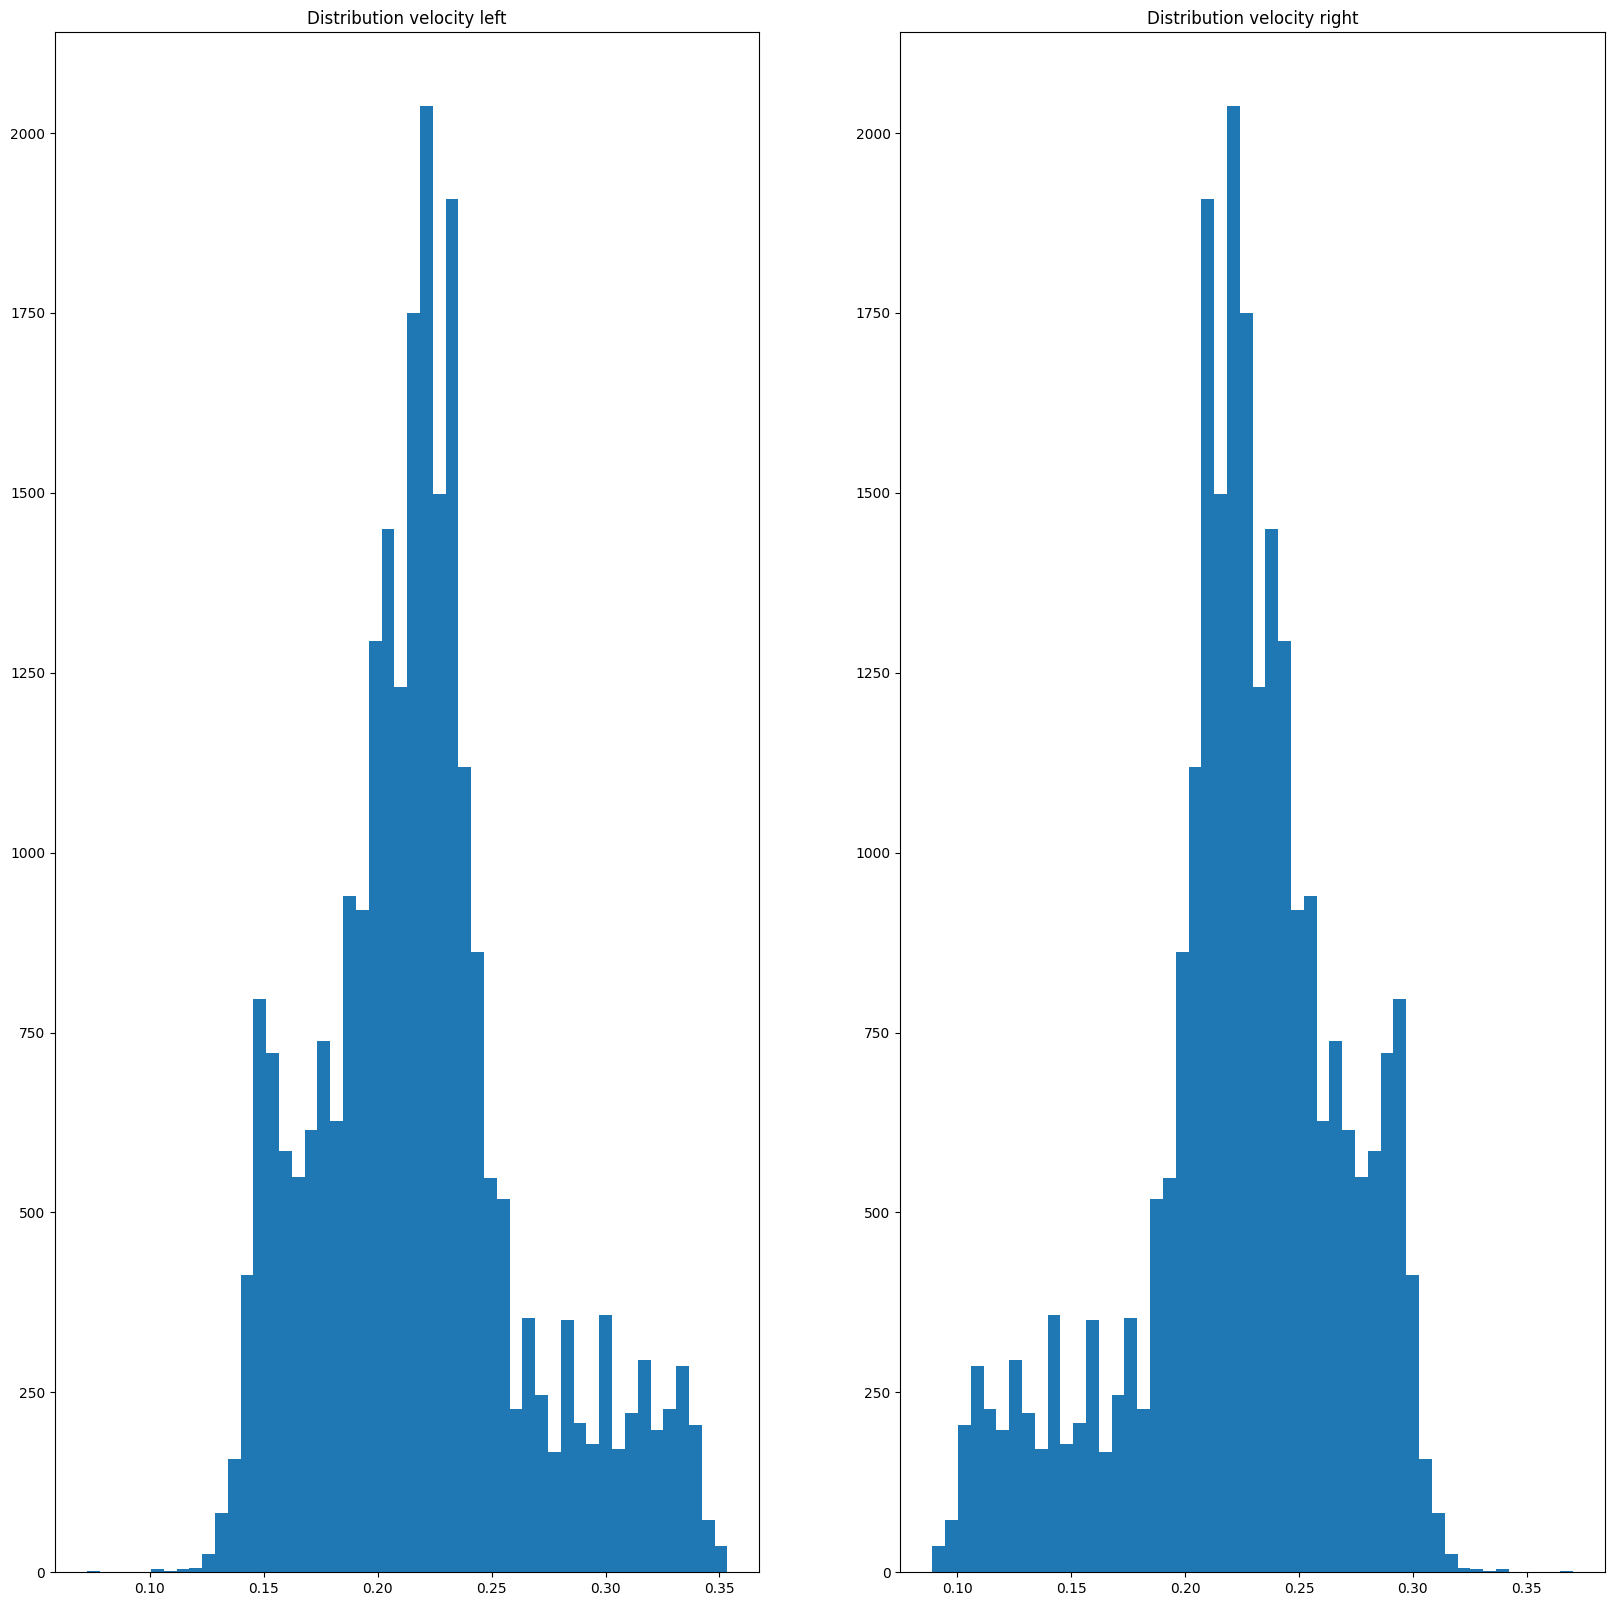

In [5]:
plt.figure(figsize=(20, 20))

plt.subplot(1,2,1)
plt.hist(df["vel_left"], bins=50)
plt.title("Distribution velocity left")

plt.subplot(1,2,2)
plt.hist(df["vel_right"], bins=50)
plt.title("Distribution velocity right")

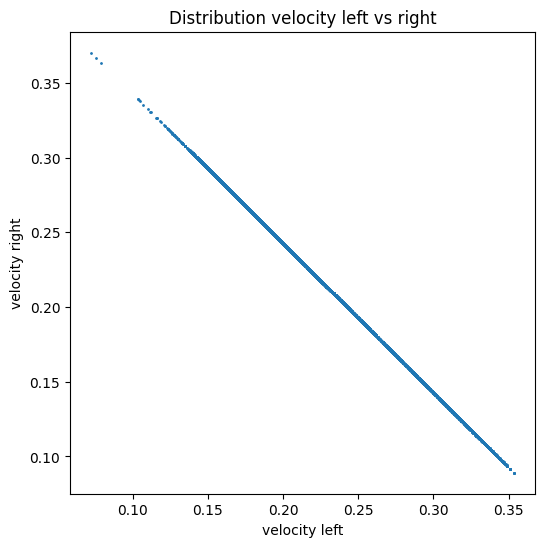

In [6]:
plt.figure(figsize=(6,6))
plt.scatter(df["vel_left"], df["vel_right"], s=1)
plt.title("Distribution velocity left vs right")
plt.xlabel("velocity left")
plt.ylabel("velocity right")
plt.show()


## Affichage des images

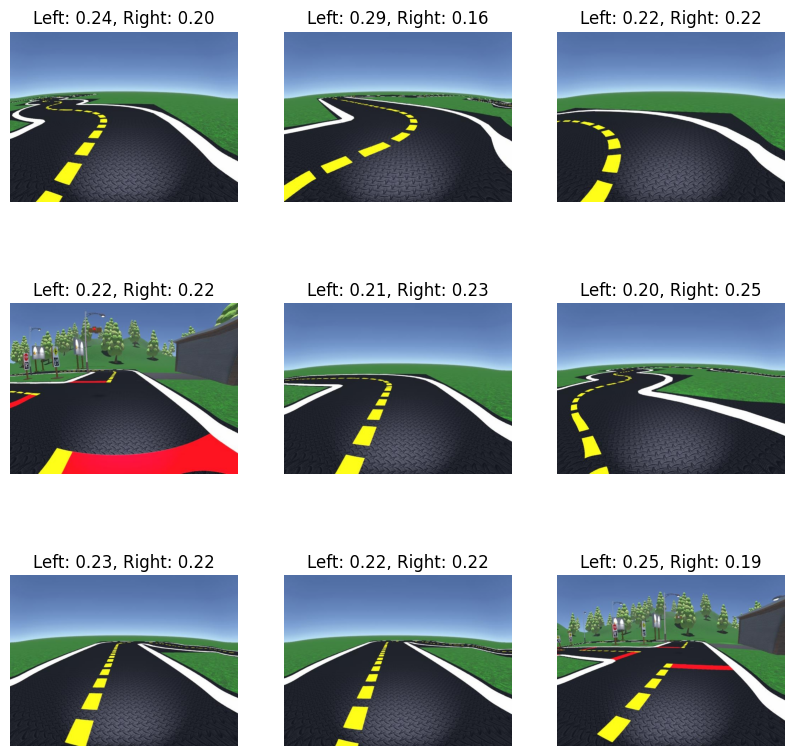

In [7]:
sample = df.sample(9)
plt.figure(figsize=(10,10))
for i, (_,row) in enumerate(sample.iterrows()):
  img = Image.open(f"{IMG_DIR}/{row.image_name}")
  plt.subplot(3, 3, i + 1)
  plt.imshow(img)
  plt.title(f"Left: {row.vel_left:.2f}, Right: {row.vel_right:.2f}")
  plt.axis("off")

# Modèle


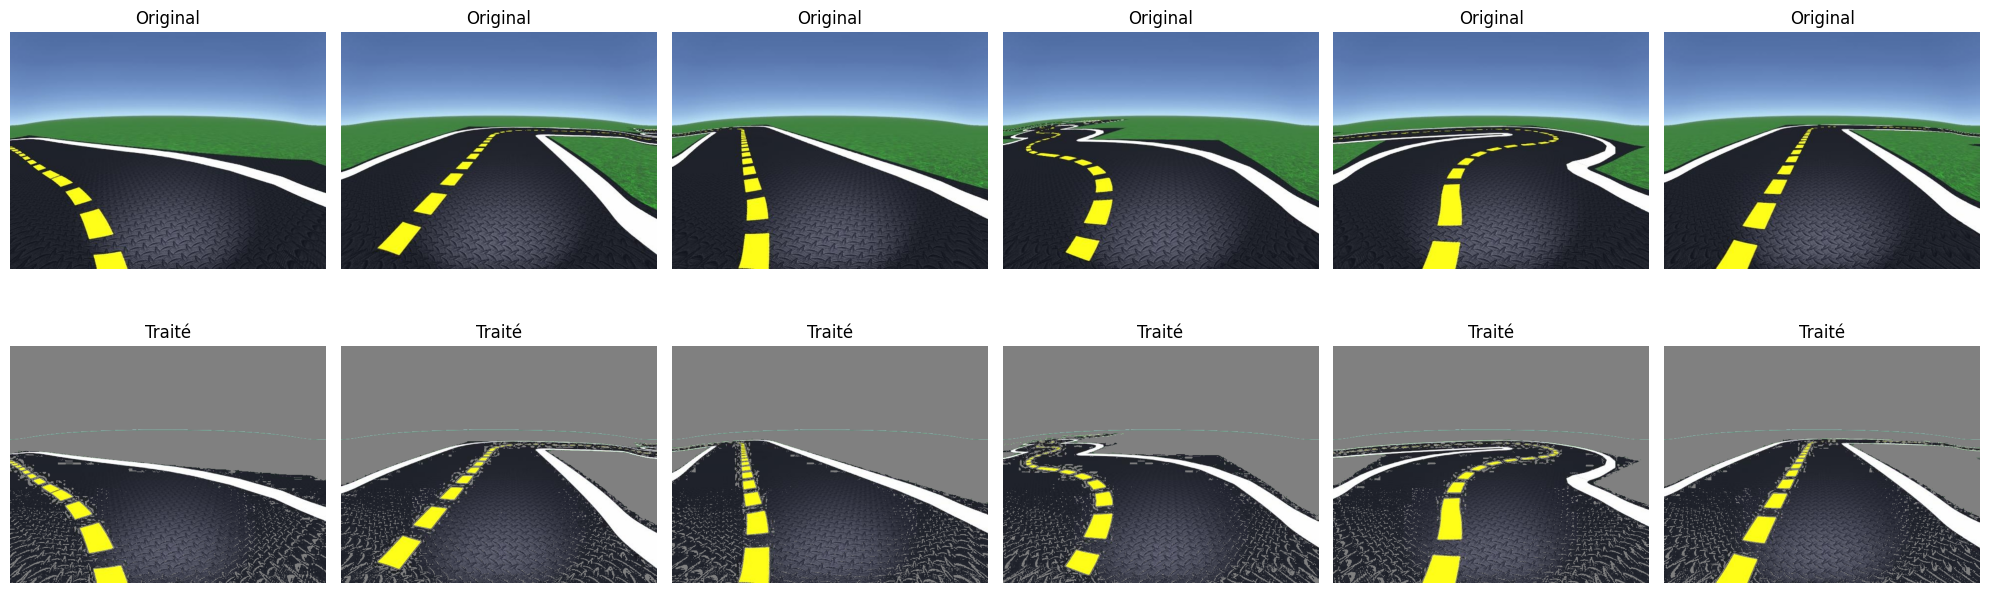

In [8]:
def preprocess_road_colors(img_pil):
    """
    Traitement des couleurs pour isoler les éléments de route :
    - Garde le jaune (ligne centrale)
    - Garde le gris/noir (surface de la route)
    - Supprime le vert (herbe/décor)
    - Supprime le bleu (ciel)
    """
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Masque jaune (ligne centrale)
    lower_yellow = np.array([15, 80, 80])
    upper_yellow = np.array([35, 255, 255])
    mask_yellow = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

    # Masque blanc (bord de route)
    lower_white = np.array([0, 0, 180])
    upper_white = np.array([180, 40, 255])
    mask_white = cv2.inRange(img_hsv, lower_white, upper_white)

    # Masque route (gris/noir foncé)
    lower_road = np.array([0, 0, 20])
    upper_road = np.array([180, 80, 200])

    mask_road = cv2.inRange(img_hsv, lower_road, upper_road)

    # Combiner jaune + blanc + route
    mask_keep = cv2.bitwise_or(mask_yellow, mask_white)
    mask_keep = cv2.bitwise_or(mask_keep, mask_road)

    # Appliquer le masque — zones non pertinentes → gris neutre (128)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result = np.full_like(img_rgb, 128)
    result[mask_keep > 0] = img_rgb[mask_keep > 0]

    return Image.fromarray(result)
    
# Visualisation sur quelques images
sample = df.sample(6)
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, (_, row) in enumerate(sample.iterrows()):
    img_orig = Image.open(f"{IMG_DIR}/{row.image_name}").convert("RGB")
    img_proc = preprocess_road_colors(img_orig)

    axes[0, i].imshow(img_orig)
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_proc)
    axes[1, i].set_title("Traité")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Transforms
train_tf = transforms.Compose([
    transforms.Lambda(preprocess_road_colors),  # traitement couleurs
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Lambda(preprocess_road_colors),  # traitement couleurs
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [10]:
# Dataset
class DuckieDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.img_dir}/{row.image_name}").convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor([row.vel_left, row.vel_right], dtype=torch.float32)

# Split + DataLoaders
full_dataset = DuckieDataset(df, IMG_DIR, transform=train_tf)
n = len(full_dataset)
n_train, n_val = int(0.70*n), int(0.15*n)
n_test = n - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 17643 | Val: 3780 | Test: 3782


## Construction du modèle

In [11]:
class DuckieNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        for name, param in backbone.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def init_and_load(checkpoint_path: str) -> "DuckieNet":
        model = DuckieNet(pretrained=False)
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
model = DuckieNet(pretrained=True).to(device)
print(f"Output shape : {model(torch.randn(2,3,224,224).to(device)).shape}")

Device : cuda
Output shape : torch.Size([2, 2])


## Entrainement du modèle

In [12]:
CHECKPOINT_DIR = r"C:\Users\Victus\Documents\duckietown\checkpoints"
DRIVE_DIR      = r"C:\Users\Victus\Documents\duckietown\checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(DRIVE_DIR,      exist_ok=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_mae = 0.0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss  = criterion(preds, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            total_mae  += (preds - labels).abs().mean().item() * imgs.size(0)
    return total_loss / len(loader.dataset), total_mae / len(loader.dataset)

history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
best_val_loss = float("inf")
NUM_EPOCHS = 20

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_mae = run_epoch(train_loader, train=True)
    vl_loss, vl_mae = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_mae"].append(tr_mae)
    history["val_mae"].append(vl_mae)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.6f} MAE: {tr_mae:.5f} | "
          f"Val Loss: {vl_loss:.6f} MAE: {vl_mae:.5f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    ckpt = {"epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(), "val_loss": vl_loss}
    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch{epoch:02d}.pt"))

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(ckpt, os.path.join(DRIVE_DIR, "best_model.pt"))
        print(f"  best_model.pt sauvegardé (val_loss={vl_loss:.6f})")

Epoch 01/20 | Train Loss: 0.004952 MAE: 0.04177 | Val Loss: 0.000676 MAE: 0.01900 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000676)
Epoch 02/20 | Train Loss: 0.001308 MAE: 0.02762 | Val Loss: 0.000636 MAE: 0.01836 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000636)
Epoch 03/20 | Train Loss: 0.000819 MAE: 0.02125 | Val Loss: 0.000602 MAE: 0.01735 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000602)
Epoch 04/20 | Train Loss: 0.000711 MAE: 0.01963 | Val Loss: 0.000539 MAE: 0.01661 | LR: 1.00e-03
  best_model.pt sauvegardé (val_loss=0.000539)
Epoch 05/20 | Train Loss: 0.000650 MAE: 0.01855 | Val Loss: 0.000561 MAE: 0.01715 | LR: 1.00e-03
Epoch 06/20 | Train Loss: 0.000644 MAE: 0.01855 | Val Loss: 0.000551 MAE: 0.01695 | LR: 1.00e-03
Epoch 07/20 | Train Loss: 0.000643 MAE: 0.01846 | Val Loss: 0.000549 MAE: 0.01640 | LR: 1.00e-03
Epoch 08/20 | Train Loss: 0.000631 MAE: 0.01828 | Val Loss: 0.000564 MAE: 0.01653 | LR: 5.00e-04
Epoch 09/20 | Train Loss: 0.000586 M

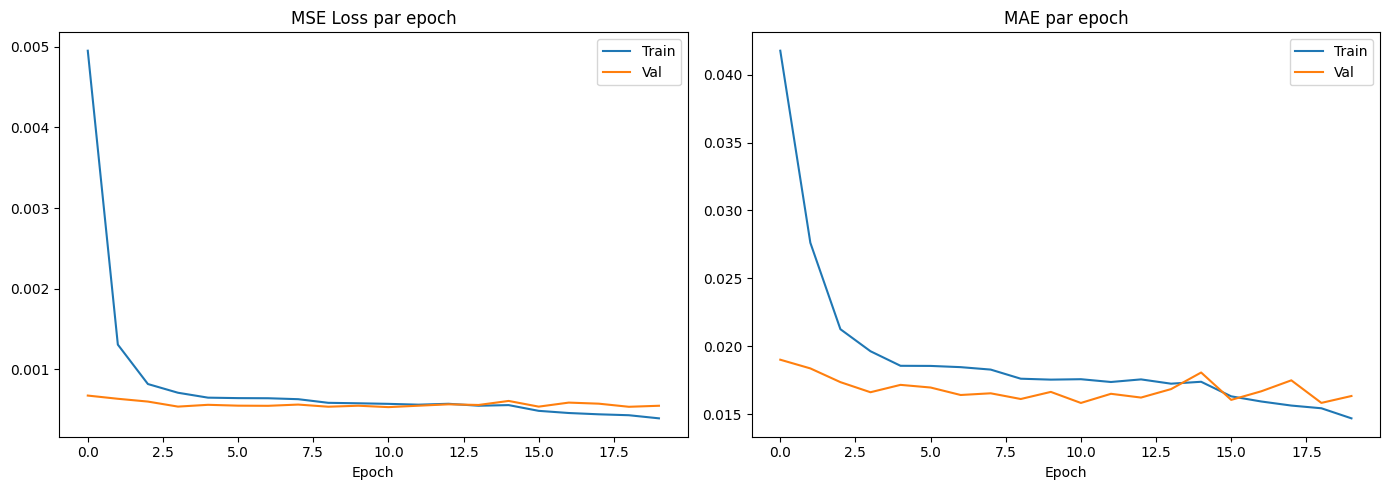

In [13]:
# Courbes de loss et MAE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("MSE Loss par epoch")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_mae"], label="Train")
ax2.plot(history["val_mae"],   label="Val")
ax2.set_title("MAE par epoch")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
# Évaluation finale sur le test set
test_loss, test_mae = run_epoch(test_loader, train=False)
print(f"Test MSE Loss : {test_loss:.6f}")
print(f"Test MAE      : {test_mae:.5f}")

Test MSE Loss : 0.000552
Test MAE      : 0.01643


In [15]:
best = DuckieNet.init_and_load(
    r"C:\Users\Victus\Documents\duckietown\checkpoints\best_model.pt"
)

# Fine-tuning
## Chargement des données 

In [34]:
FINETUNE_ROOT  = r"C:\Users\Victus\Documents\heig_vd\iaa\labos\IAA\lab2_part1"
FINETUNE_CSV    = FINETUNE_ROOT  + r"\labels.csv"
FINETUNE_IMG     = FINETUNE_ROOT  + r"\images"

df_ft = pd.read_csv(FINETUNE_CSV)
print(f"Données collectées : {len(df_ft)} samples")

df_ft_train, df_ft_val = train_test_split(df_ft, test_size=0.2, random_state=42)
df_ft_train = df_ft_train.reset_index(drop=True)
df_ft_val   = df_ft_val.reset_index(drop=True)

print(f"Train: {len(df_ft_train)} | Val: {len(df_ft_val)}")

Données collectées : 7198 samples
Train: 5758 | Val: 1440


## Transforms et augmentation

In [35]:
train_tf_ft = transforms.Compose([
    transforms.Lambda(preprocess_road_colors),
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tf_ft = transforms.Compose([
    transforms.Lambda(preprocess_road_colors),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [36]:
finetune_dataset_train = DuckieDataset(df_ft_train, FINETUNE_IMG, transform=train_tf_ft)
finetune_dataset_val   = DuckieDataset(df_ft_val,   FINETUNE_IMG, transform=val_tf_ft)

ft_train_loader = DataLoader(finetune_dataset_train, batch_size=16, shuffle=True,  num_workers=0, pin_memory=False)
ft_val_loader   = DataLoader(finetune_dataset_val,   batch_size=16, shuffle=False, num_workers=0, pin_memory=False)


## Fine-tuning loop

In [47]:
CHECKPOINT_DIR = r"C:\Users\Victus\Documents\duckietown\checkpoints"
model_ft = DuckieNet.init_and_load(
    r"C:\Users\Victus\Documents\duckietown\checkpoints\best_model.pt"
)
model_ft = model_ft.to(device)

# Dégeler toutes les couches
for name, param in model_ft.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

criterion_ft = nn.MSELoss()
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()), lr=1e-5
)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, patience=2, factor=0.5)

In [48]:
def run_epoch_ft(loader, train=True):
    model_ft.train() if train else model_ft.eval()
    total_loss, total_mae = 0.0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_ft(imgs)
            loss  = criterion_ft(preds, labels)
            if train:
                optimizer_ft.zero_grad()
                loss.backward()
                optimizer_ft.step()
            total_loss += loss.item() * imgs.size(0)
            total_mae  += (preds - labels).abs().mean().item() * imgs.size(0)
    return total_loss / len(loader.dataset), total_mae / len(loader.dataset)

In [49]:
ft_history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
best_ft_loss = float("inf")
NUM_EPOCHS_FT = 20

for epoch in range(1, NUM_EPOCHS_FT + 1):
    tr_loss, tr_mae = run_epoch_ft(ft_train_loader, train=True)
    vl_loss, vl_mae = run_epoch_ft(ft_val_loader,   train=False)
    scheduler_ft.step(vl_loss)

    ft_history["train_loss"].append(tr_loss)
    ft_history["val_loss"].append(vl_loss)
    ft_history["train_mae"].append(tr_mae)
    ft_history["val_mae"].append(vl_mae)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_FT} | "
          f"Train Loss: {tr_loss:.6f} MAE: {tr_mae:.5f} | "
          f"Val Loss: {vl_loss:.6f} MAE: {vl_mae:.5f} | "
          f"LR: {optimizer_ft.param_groups[0]['lr']:.2e}")

    ckpt_ft = {"epoch": epoch, "model_state_dict": model_ft.state_dict(),
               "optimizer_state_dict": optimizer_ft.state_dict(), "val_loss": vl_loss}
    torch.save(ckpt_ft, os.path.join(CHECKPOINT_DIR, f"finetune_epoch{epoch:02d}.pt"))

    if vl_loss < best_ft_loss:
        best_ft_loss = vl_loss
        torch.save(ckpt_ft, os.path.join(CHECKPOINT_DIR, "best_finetuned_model.pt"))
        print(f"  best_finetuned_model.pt sauvegardé (val_loss={vl_loss:.6f})")

Epoch 01/20 | Train Loss: 0.042484 MAE: 0.16894 | Val Loss: 0.027876 MAE: 0.13058 | LR: 1.00e-05
  best_finetuned_model.pt sauvegardé (val_loss=0.027876)
Epoch 02/20 | Train Loss: 0.030351 MAE: 0.13687 | Val Loss: 0.025413 MAE: 0.12348 | LR: 1.00e-05
  best_finetuned_model.pt sauvegardé (val_loss=0.025413)
Epoch 03/20 | Train Loss: 0.028777 MAE: 0.13401 | Val Loss: 0.023956 MAE: 0.11965 | LR: 1.00e-05
  best_finetuned_model.pt sauvegardé (val_loss=0.023956)
Epoch 04/20 | Train Loss: 0.027821 MAE: 0.13211 | Val Loss: 0.023071 MAE: 0.11662 | LR: 1.00e-05
  best_finetuned_model.pt sauvegardé (val_loss=0.023071)
Epoch 05/20 | Train Loss: 0.026076 MAE: 0.12774 | Val Loss: 0.021636 MAE: 0.11379 | LR: 1.00e-05
  best_finetuned_model.pt sauvegardé (val_loss=0.021636)
Epoch 06/20 | Train Loss: 0.024741 MAE: 0.12398 | Val Loss: 0.020576 MAE: 0.11047 | LR: 1.00e-05
  best_finetuned_model.pt sauvegardé (val_loss=0.020576)
Epoch 07/20 | Train Loss: 0.023607 MAE: 0.12091 | Val Loss: 0.019881 MAE: 0.

## Courbe fine-tuning

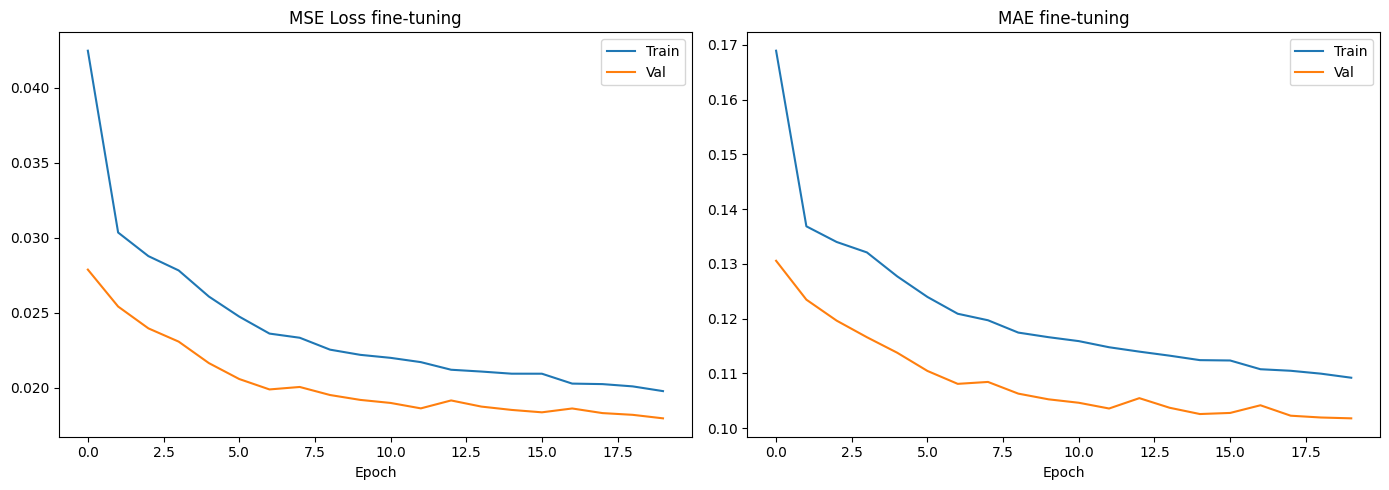

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ft_history["train_loss"], label="Train")
ax1.plot(ft_history["val_loss"],   label="Val")
ax1.set_title("MSE Loss fine-tuning")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(ft_history["train_mae"], label="Train")
ax2.plot(ft_history["val_mae"],   label="Val")
ax2.set_title("MAE fine-tuning")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

## Vérification init_and_load

In [52]:
best_ft = DuckieNet.init_and_load(
    r"C:\Users\Victus\Documents\duckietown\checkpoints\best_finetuned_model.pt"
)
print("best_finetuned_model.pt chargé via init_and_load")

best_finetuned_model.pt chargé via init_and_load
